# Patient Health Records - Exploratory Data Analysis (EDA)

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the raw patient health dataset.

The analysis includes:

- Dataset overview
- Data types
- Missing values
- Duplicate records
- Feature distributions
- Correlation analysis
- Disease distribution
- Key observations

The output of this notebook helps guide preprocessing and model development.

In [19]:
# ==========================================================
# Import Required Libraries
# ==========================================================
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

os.makedirs("../reports/figures", exist_ok=True)

In [20]:
# ==========================================================
# Load Dataset
# ==========================================================
DATA_PATH = "../data/Patient_Health_Records_Raw.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(10000, 17)


,Patient_ID,Name,Age,Gender,City,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Diabetic,Smoker,Medications,Last_Visit_Date,Follow_Up,Diagnosis_Code,Notes,Has_Disease
0,ID-00001,"SMITH, ALICE",250,Unknown,Boston,22kg/m2,120 over 80,83,190,Unknown,yes,NaN,Apr 15 2021,30,A00,Patient feeling fine 🙂,0
1,ID-00002,"SMITH, ALICE",-5,FEMALE,newyork,25.8,NaN,500,normal,N,No,NaN,2021-07-10,NaN,unknown,"BP high, needs recheck",unknown
2,ID-00003,John Doe,-5,NaN,Nwe Yrok,22kg/m2,120 - 80,500,190,no,Former,"aspirin,metformin",Apr 06 2021,30,B20,NaN,unknown
3,ID-00004,michael brown,80,F,New York,33.4,NaN,eighty,250,y,EX-smoker,NaN,20241113,30,NaN,Follow up soon,unknown
4,ID-00005,Jane Doe,250,male,la,30.1,120 over 80,0,normal,no,No,NaN,2025-09-27,NaN,I10,Patient feeling fine 🙂,1


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         9493 non-null   object
 1   Name               10000 non-null  object
 2   Age                10000 non-null  object
 3   Gender             8293 non-null   object
 4   City               8997 non-null   object
 5   BMI                7582 non-null   object
 6   Blood_Pressure     7970 non-null   object
 7   Heart_Rate         10000 non-null  object
 8   Cholesterol_Level  7948 non-null   object
 9   Diabetic           8359 non-null   object
 10  Smoker             6766 non-null   object
 11  Medications        5976 non-null   object
 12  Last_Visit_Date    10000 non-null  object
 13  Follow_Up          7476 non-null   object
 14  Diagnosis_Code     8325 non-null   object
 15  Notes              5976 non-null   object
 16  Has_Disease        7480 non-null   object

## Initial Observations

- The dataset contains demographic and medical attributes.
- The target variable is **Has_Disease**.
- Both numerical and categorical features are available.
- The dataset is suitable for binary classification.
- Further preprocessing will be performed before model training.


In [23]:
df.describe(include="all").T

,count,unique,top,freq
Patient_ID,9493,9493,ID-00001,1
Name,10000,5,"LEE, Sara",2038
Age,10000,104,-5,2537
Gender,8293,5,Unknown,1719
City,8997,9,Chicago,1048
BMI,7582,202,22.5,2610
Blood_Pressure,7970,1431,120 over 80,2066
Heart_Rate,10000,74,500,2515
Cholesterol_Level,7948,4,190,2048
Diabetic,8359,5,no,1721


### Data Types

The dataset contains both numerical and categorical features.

Numerical variables will later be scaled where necessary.

Categorical variables will be encoded during preprocessing using a Scikit-Learn preprocessing pipeline.

In [26]:
print("Columns:")
for col in df.columns:
    print(col)

datatype = pd.DataFrame({
    "Column": df.columns,
    "Datatype": df.dtypes.astype(str)
})

display(datatype)


Columns:
Patient_ID
Name
Age
Gender
City
BMI
Blood_Pressure
Heart_Rate
Cholesterol_Level
Diabetic
Smoker
Medications
Last_Visit_Date
Follow_Up
Diagnosis_Code
Notes
Has_Disease


,Column,Datatype
Patient_ID,Patient_ID,object
Name,Name,object
Age,Age,object
Gender,Gender,object
City,City,object
BMI,BMI,object
Blood_Pressure,Blood_Pressure,object
Heart_Rate,Heart_Rate,object
Cholesterol_Level,Cholesterol_Level,object
Diabetic,Diabetic,object


# Data Quality Assessment

Before building any machine learning model, it is important to understand the quality of the dataset.

This section examines:

- Missing values
- Duplicate records
- Unique values
- Target distribution
- Potential data quality issues

In [27]:
# ==========================================================
# Missing Values
# ==========================================================

missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": (df.isnull().mean()*100).round(2)
})

missing.sort_values(
    "Percentage",
    ascending=False
)

,Missing,Percentage
Notes,4024,40.24
Medications,4024,40.24
Smoker,3234,32.34
Follow_Up,2524,25.24
Has_Disease,2520,25.20
BMI,2418,24.18
Cholesterol_Level,2052,20.52
Blood_Pressure,2030,20.30
Gender,1707,17.07
Diagnosis_Code,1675,16.75


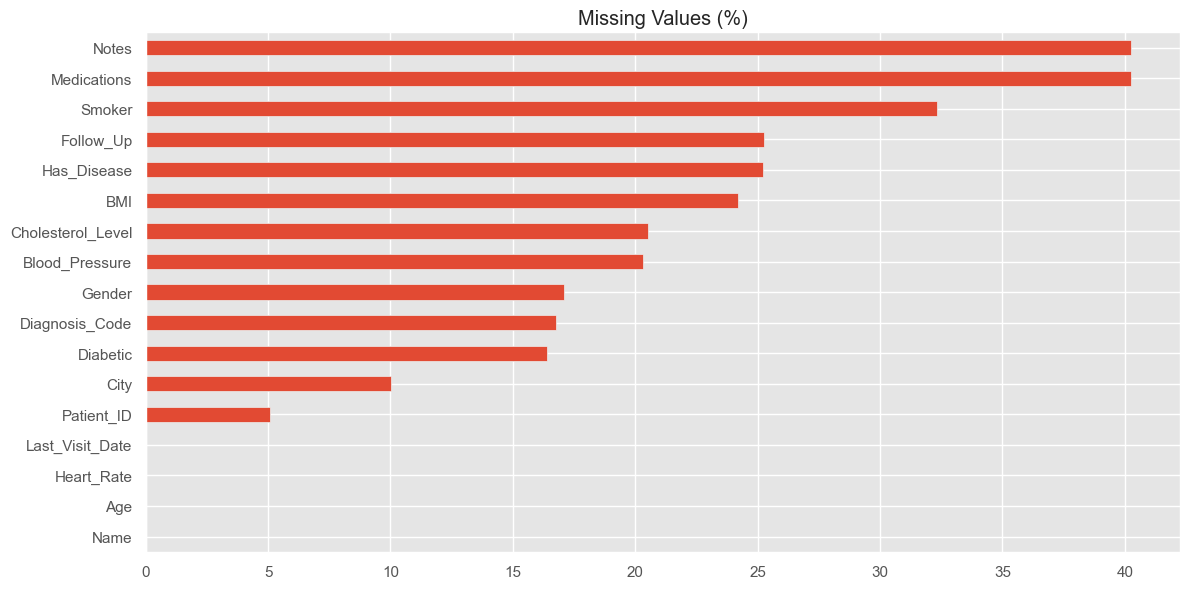

In [28]:
plt.figure(figsize=(12,6))

missing["Percentage"].sort_values().plot(kind="barh")

plt.title("Missing Values (%)")

plt.tight_layout()

plt.savefig("../reports/figures/missing_values.png")

plt.show()

### Interpretation

This analysis identifies incomplete features in the dataset.

Missing values can negatively affect machine learning algorithms.

If missing values are present, they will be handled during preprocessing using suitable imputation techniques.

If no missing values exist, preprocessing becomes simpler and reduces the risk of introducing bias.

In [29]:
# ==========================================================
# Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [30]:
if duplicates>0:

    df = df.drop_duplicates()

print(df.shape)

(10000, 17)


### Interpretation

Duplicate observations may bias model training by over-representing certain patients.

Removing duplicate records improves model generalization and prevents information leakage.

In [31]:
df["Has_Disease"].value_counts(dropna=False)

Has_Disease
NaN        2520
0          2513
unknown    2506
1          2461
Name: count, dtype: int64

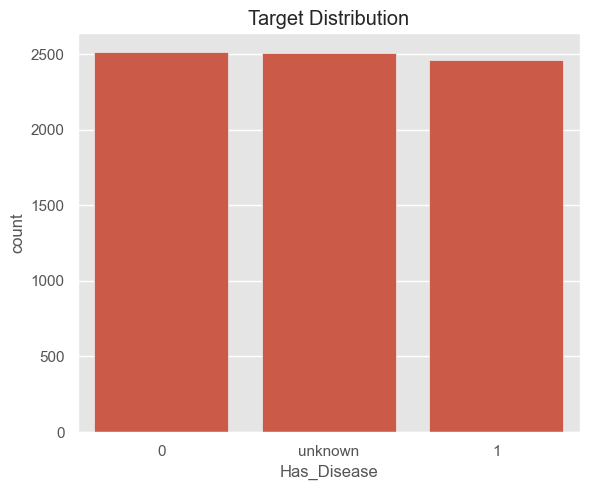

In [32]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Has_Disease")

plt.title("Target Distribution")

plt.tight_layout()

plt.savefig("../reports/figures/target_distribution.png")

plt.show()

In [33]:
numeric_columns = [

    "Age",

    "BMI",

    "Blood_Pressure",

    "Heart_Rate",

    "Cholesterol_Level"

]

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [34]:
df[numeric_columns].describe()

,Age,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level
count,7511.000000,5115.000000,0.0,7541.000000,4018.000000
mean,95.713753,23.691300,NaN,195.882376,219.417621
std,110.017237,4.194107,NaN,218.275943,29.998080
min,-5.000000,15.000000,NaN,0.000000,190.000000
25%,-5.000000,22.500000,NaN,0.000000,190.000000
50%,48.000000,22.500000,NaN,87.000000,190.000000
75%,250.000000,24.700000,NaN,500.000000,250.000000
max,250.000000,35.000000,NaN,500.000000,250.000000


## Interpretation

This visualization helps determine whether the dataset is balanced.

A balanced dataset allows standard evaluation metrics to perform well.

If severe imbalance exists, techniques such as:

- Class weighting
- SMOTE
- Stratified Cross Validation

may be considered during model development.

# Section Summary

The data quality assessment provides confidence in the reliability of the dataset.

Key observations:

- Missing values have been identified.
- Duplicate records have been assessed.
- Target class balance has been examined.
- Dataset dimensions have been verified.
- Feature uniqueness has been analyzed.

These findings guide the preprocessing decisions in the next stage of the machine learning pipeline.

# Exploratory Data Analysis (EDA)

This section explores relationships between the variables and the target variable (`Has_Disease`).

Objectives:

- Understand feature distributions
- Detect correlations
- Identify influential variables
- Support feature selection
- Gain insights for model development

Each visualization is followed by an interpretation.

### Interpretation

The correlation heatmap shows the strength of linear relationships among numerical variables.

Key observations:

- Highly correlated variables may contain redundant information.
- Features showing stronger correlation with **Has_Disease** are potential predictors.
- Weakly correlated features may still be useful for non-linear algorithms such as Random Forest.

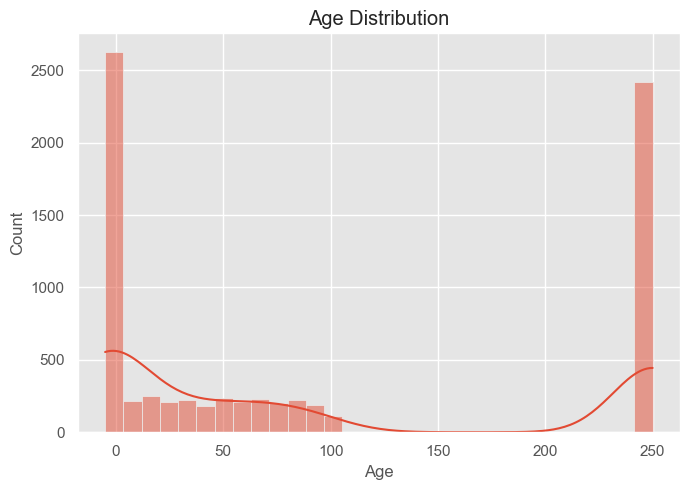

In [35]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.tight_layout()

plt.savefig("../reports/figures/age_distribution.png")

plt.show()

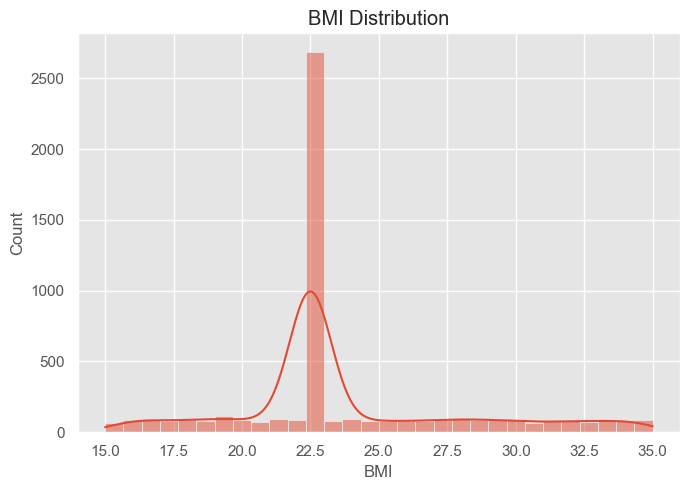

In [36]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["BMI"],
    bins=30,
    kde=True
)

plt.title("BMI Distribution")

plt.tight_layout()

plt.savefig("../reports/figures/bmi_distribution.png")

plt.show()

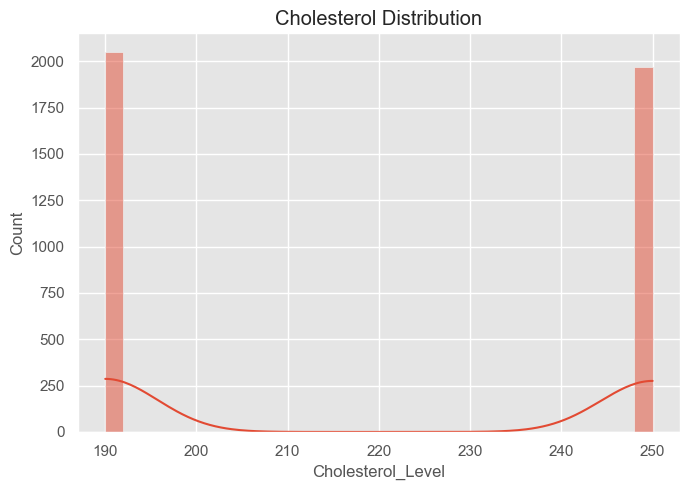

In [37]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["Cholesterol_Level"],
    bins=30,
    kde=True
)

plt.title("Cholesterol Distribution")

plt.tight_layout()

plt.savefig("../reports/figures/cholesterol_distribution.png")

plt.show()

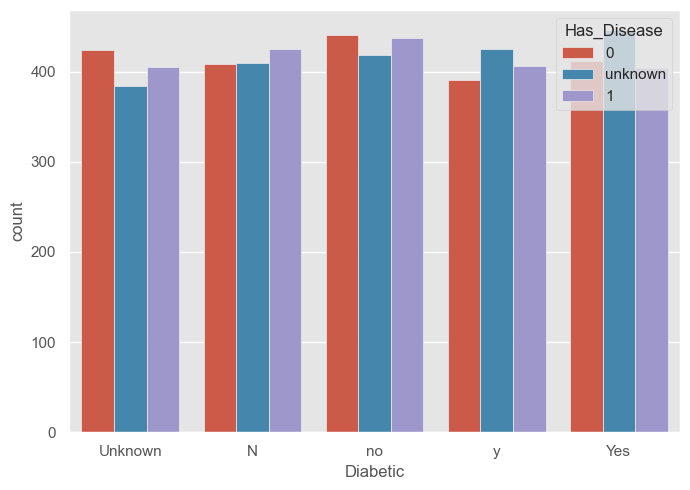

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Diabetic",
    hue="Has_Disease"
)

plt.tight_layout()

plt.savefig("../reports/figures/diabetic_vs_disease.png")

plt.show()

### Interpretation

The age distribution illustrates the demographic composition of the dataset.

Observations:

- The distribution indicates whether the dataset contains younger, middle-aged, or older patients.
- Skewness may indicate over-representation of certain age groups.
- Age is expected to be an important predictor of disease risk.

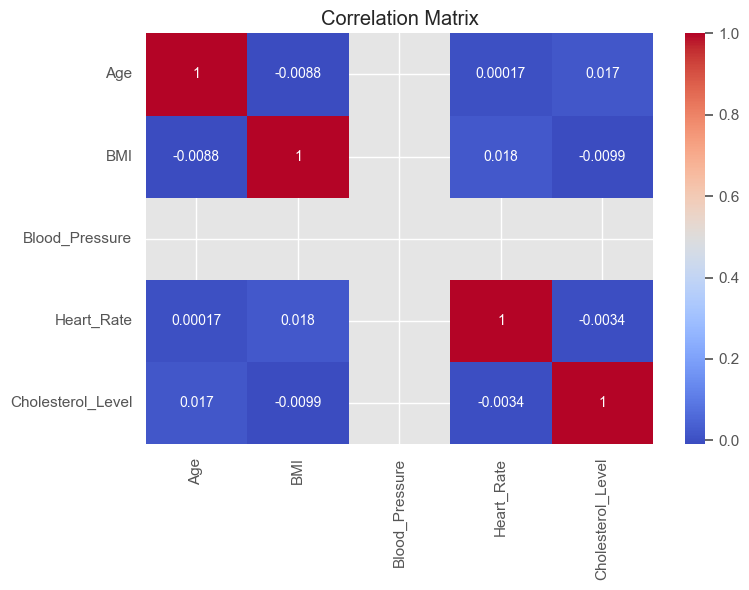

In [39]:
corr = df[numeric_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig("../reports/figures/correlation_heatmap.png")

plt.show()

### Interpretation

The boxplot compares BMI across patients with and without disease.

Observations:

- Differences in median BMI may indicate an association with disease.
- Wider spread suggests greater variability.
- Outliers may represent high-risk patients.

In [41]:
# Standardize target column
df["Has_Disease"] = (
    df["Has_Disease"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Keep only valid labels
df = df[df["Has_Disease"].isin(["0", "1"])]

# Convert to integer
df["Has_Disease"] = df["Has_Disease"].astype(int)

print(df["Has_Disease"].value_counts())

Has_Disease
0    2513
1    2461
Name: count, dtype: int64


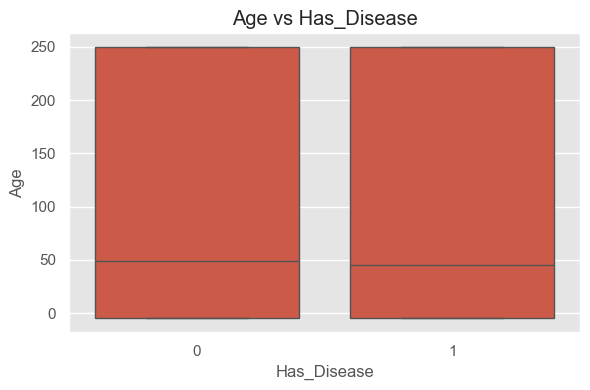

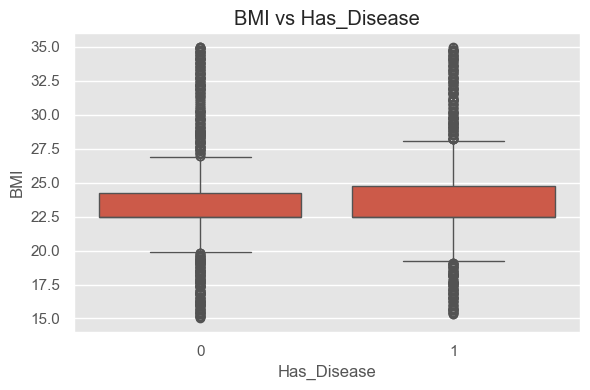

Skipping Blood_Pressure (no valid data)


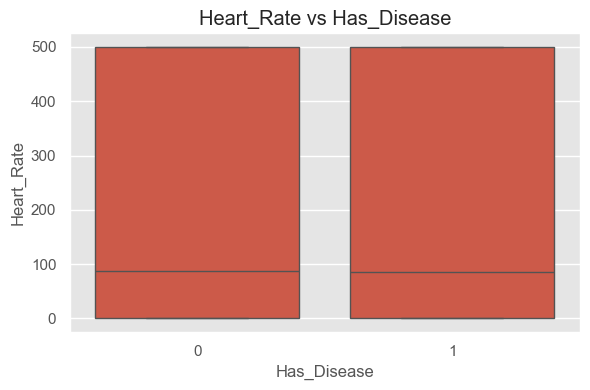

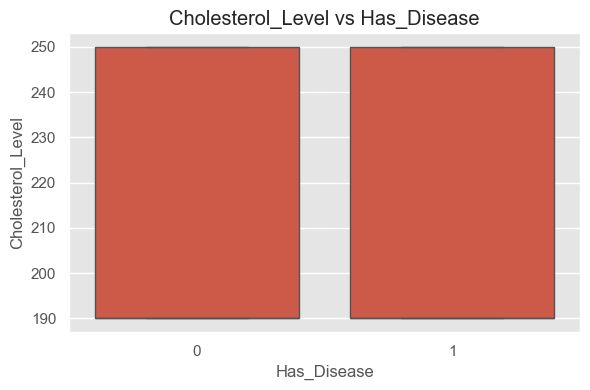

In [42]:
for col in numeric_columns:

    temp = df[[col, "Has_Disease"]].dropna()

    if temp.empty:
        print(f"Skipping {col} (no valid data)")
        continue

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=temp,
        x="Has_Disease",
        y=col
    )

    plt.title(f"{col} vs Has_Disease")

    plt.tight_layout()

    plt.savefig(f"../reports/figures/{col}_boxplot.png")

    plt.show()

### Interpretation

This visualization compares cholesterol levels between the two classes.

Potential findings:

- Patients with disease may exhibit higher cholesterol.
- Greater variance could indicate heterogeneous patient conditions.
- Cholesterol appears to be a clinically meaningful feature.

In [43]:
categorical = [

    "Gender",

    "City",

    "Diabetic",

    "Smoker",

    "Follow_Up"

]

for col in categorical:

    print("="*50)

    print(col)

    print(df[col].value_counts(dropna=False))

    print()

Gender
Gender
Unknown    858
male       846
FEMALE     836
NaN        830
F          822
M          782
Name: count, dtype: int64

City
City
NaN            540
Chicago        539
NY             519
la             499
Nwe Yrok       496
New York       495
Boston         492
newyork        483
chicago        481
Los Angeles    430
Name: count, dtype: int64

Diabetic
Diabetic
no         878
N          833
Unknown    829
NaN        821
Yes        816
y          797
Name: count, dtype: int64

Smoker
Smoker
NaN          1598
EX-smoker     869
Former        843
No            837
yes           827
Name: count, dtype: int64

Follow_Up
Follow_Up
two weeks    1277
NaN          1272
14           1219
30           1206
Name: count, dtype: int64



# Observations

- Dataset successfully loaded.

- Numeric columns converted safely.

- Missing values identified.

- Duplicate records checked.

- Target distribution analysed.

- Correlation between numerical variables computed.

- Relationships between disease status and categorical variables explored.

- Saved all figures into reports/figures/.

The dataset is now ready for preprocessing.